Problem formations
1. we want to understand which variables is needed
2. we want to predict car prices

In [3]:
#loading the raw data
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pickle
import plotly.express as px
import streamlit as st

In [16]:
import openpyxl
car_data = pd.read_csv("car_data.csv")

In [17]:
car_data.head()

,index,Make,Model,Year,Trim,MSRP,Invoice Price,Used/New Price,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,0,Aston Martin,DBX707,2024,Base,"$242,000",NaN,"$242,000",Large,SUV,V8,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,20 mpg
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$33,653","$35,800",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$35,533","$37,800",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$38,917","$41,400",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$37,037","$39,400",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg


2. Data Preprocessing steps
   2.1 Understanding the Car Data

In [20]:
#investigate all elements within each features
for column in car_data:
    unique_values = np.unique(car_data[column].fillna("0"))
    nr_values = len(unique_values)
    if nr_values <= 12:
        print("the number of values for features{} :{} -- {}".format(column, nr_values, unique_values))
    else:
        print("The number of values for feature {} :{}".format(column, nr_values))

The number of values for feature index :1610
the number of values for featuresMake :7 -- ['Aston Martin' 'Audi' 'BMW' 'Bentley' 'Ford' 'Mercedes-Benz' 'Nissan']
The number of values for feature Model :150
the number of values for featuresYear :2 -- [2023 2024]
The number of values for feature Trim :373
The number of values for feature MSRP :1317
The number of values for feature Invoice Price :944
The number of values for feature Used/New Price :1317
the number of values for featuresBody Size :3 -- ['Compact' 'Large' 'Midsize']
the number of values for featuresBody Style :12 -- ['Cargo Minivan' 'Cargo Van' 'Convertible' 'Convertible SUV' 'Coupe'
 'Hatchback' 'Passenger Minivan' 'Passenger Van' 'Pickup Truck' 'SUV'
 'Sedan' 'Wagon']
the number of values for featuresCylinders :10 -- ['0' 'I3' 'I4' 'I5' 'I6' 'V10' 'V12' 'V6' 'V8' 'W12']
the number of values for featuresEngine Aspiration :6 -- ['Electric Motor' 'Naturally Aspirated' 'Supercharged' 'Turbocharged'
 'Twin-Turbo' 'Twincharged']

In [27]:
#checking for null values
car_data.isnull().sum()

index                 0
Make                  0
Model                 0
Year                  0
Trim                  0
MSRP                  0
Used/New Price        0
Body Size             0
Body Style            0
Engine Aspiration     0
Drivetrain            0
Transmission          0
Horsepower            5
Torque               27
Horsepower_No         5
dtype: int64

4.2 Dealing with missing values


In [22]:
#dropping columns that has up to 50% missing values
car_data = car_data.drop(["Invoice Price", "Cylinders", "Highway Fuel Economy"], axis=1)

In [ ]:
#dealin with the columns that have missing values
car_data.head()

#creating new columns for horsepower and torque so it be numerical
car_data["Horsepower_No"] = car_data["Horsepower"].str[0:3].astype(float)

#viewing the null values 
#car_data[car_data["Horsepower_No"].isna()]

#calculating the mean for ford cars
mean_horsepower = car_data["Horsepower_No"][car_data["Make"] == "Ford"].mean()

#filling in the null value with the mean
car_data["Horsepower_No"] = car_data["Horsepower_No"].fillna(mean_horsepower)
car_data["Horsepower"] = car_data["Horsepower"].fillna(mean_horsepower)

car_data.isnull().sum()

In [31]:
#creating a new column just for number
car_data["Torque_No"] = car_data["Torque"].str[0:3].astype(float)


#calculating the mean fofr all cars

mean_torque = car_data["Torque_No"].mean()

#filling in the null value with the mean

car_data["Torque_No"] = car_data["Torque_No"].fillna(mean_torque)
car_data["Torque"] = car_data["Torque"].fillna(mean_torque)

car_data.isnull().sum()

index                0
Make                 0
Model                0
Year                 0
Trim                 0
MSRP                 0
Used/New Price       0
Body Size            0
Body Style           0
Engine Aspiration    0
Drivetrain           0
Transmission         0
Horsepower           0
Torque               0
Horsepower_No        0
Torque_No            0
dtype: int64

4.3 Cleaning data types

In [40]:
#cleaning stopwords($,commas, etc) from MSRP
car_data["MSRP"] = car_data["MSRP"].str.replace("$","")
car_data["MSRP"] = car_data["MSRP"].str.replace(",","").astype(float)

car_data["Used/New Price"] = car_data["Used/New Price"].str.replace("$","")


In [37]:
car_data["Used/New Price"] = car_data["Used/New Price"].str.replace(",","").astype(float)

4.3 **Visualising Data**

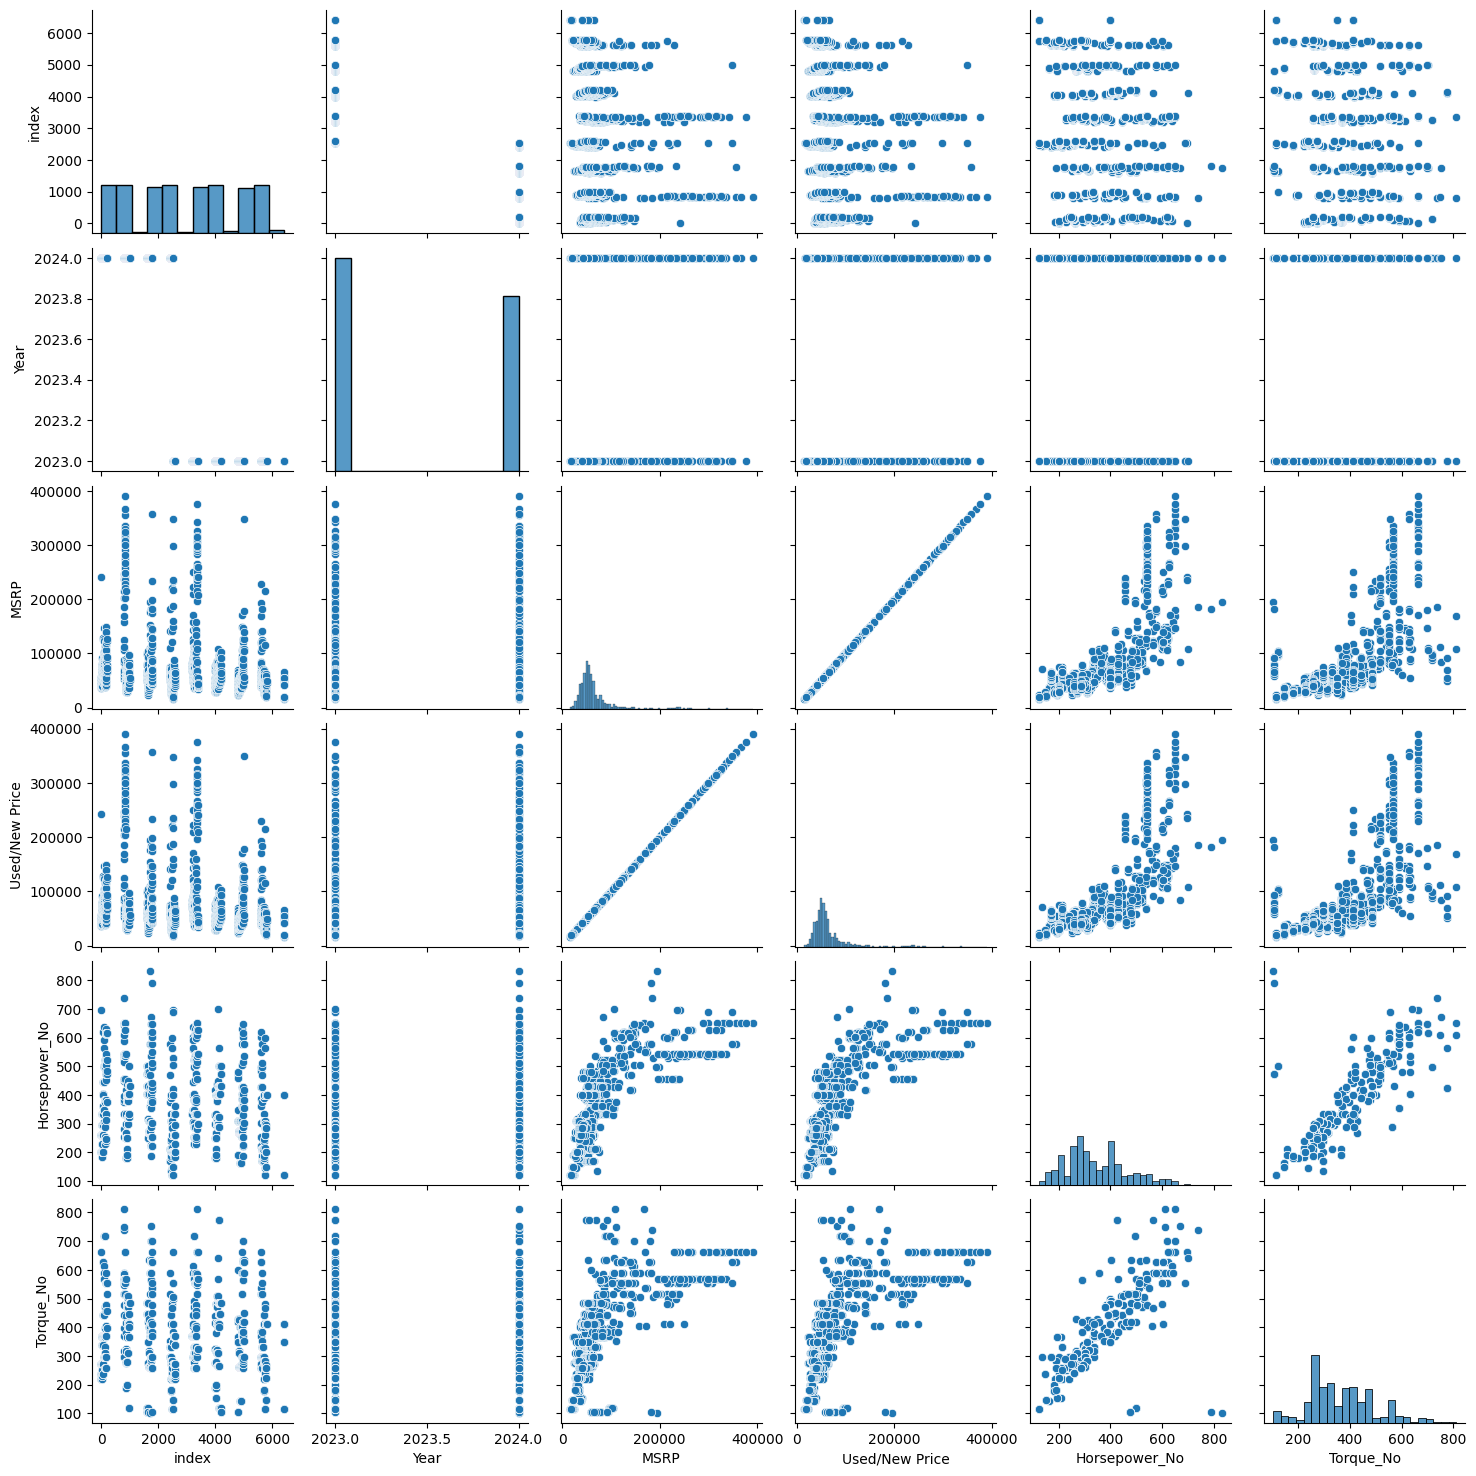

In [42]:
import seaborn as sns
#example1 - visualising the entire datasets

ex1 = sns.pairplot(car_data)


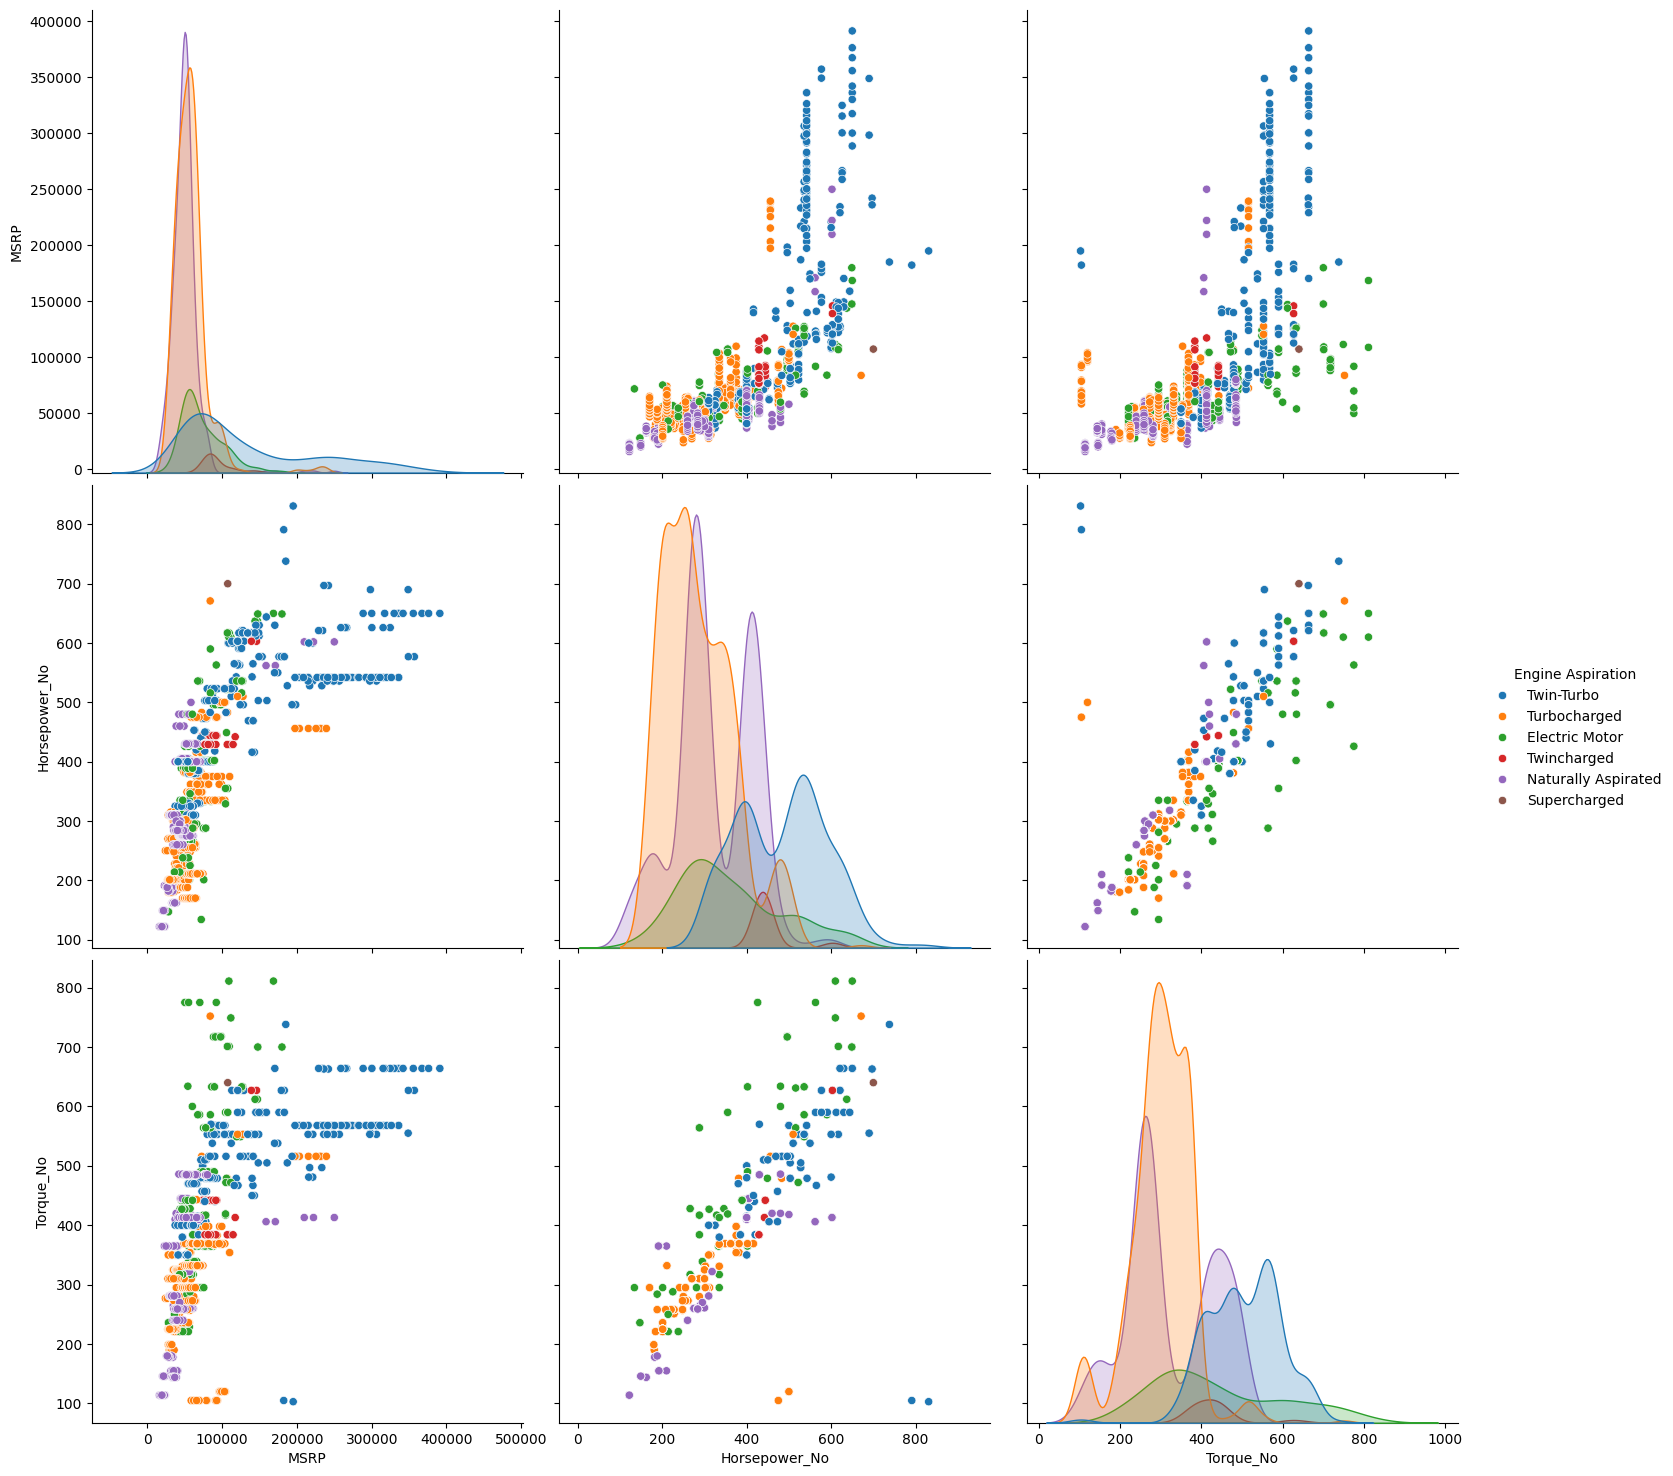

In [44]:
#example2  visualizing a subset of our data - important features

ex2 = sns.pairplot(car_data[["MSRP", "Horsepower_No", "Torque_No", "Engine Aspiration"]], hue = "Engine Aspiration", height = 5)

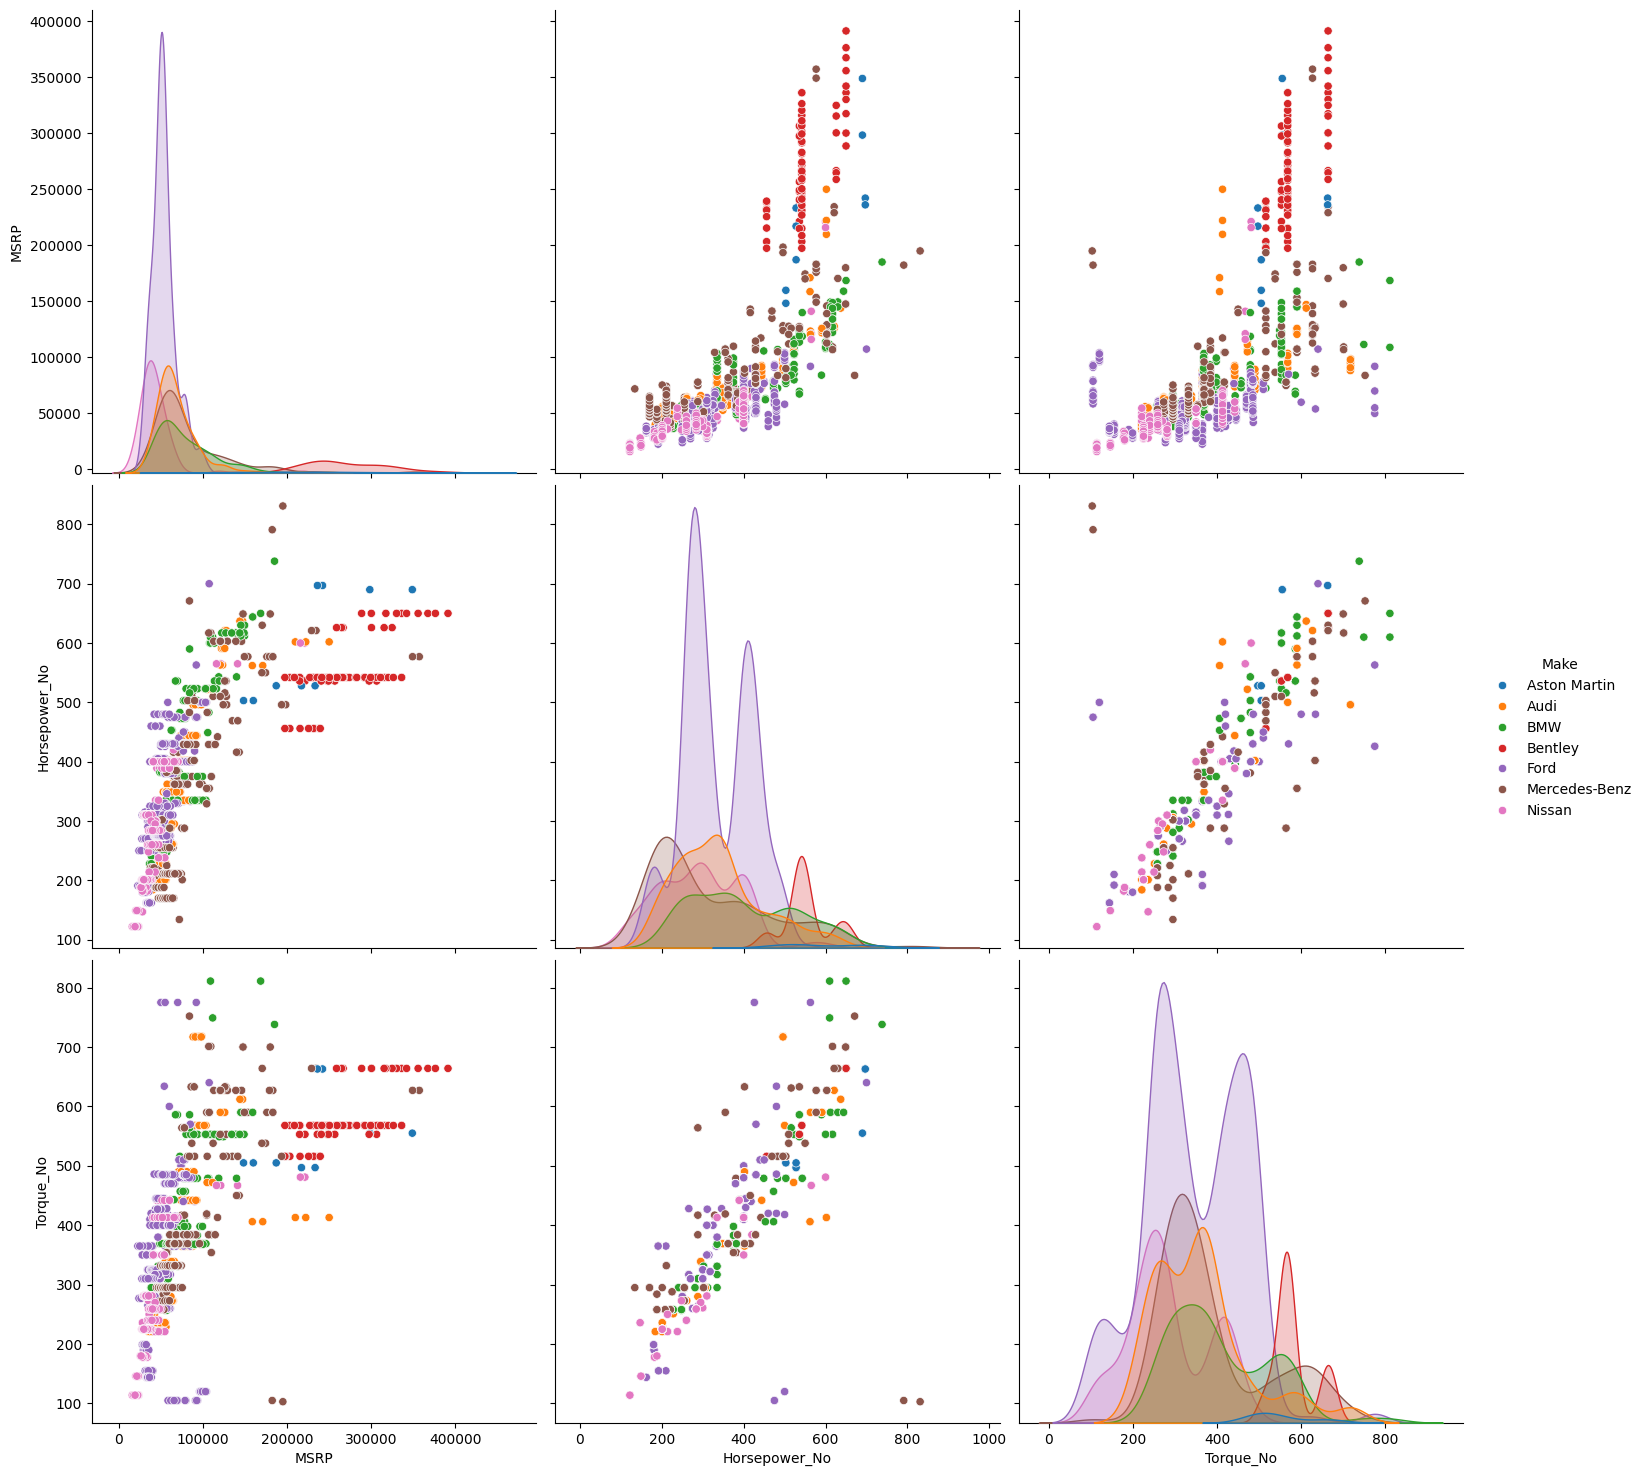

In [45]:
ex2 = sns.pairplot(car_data[["MSRP", "Horsepower_No", "Torque_No", "Make"]], hue = "Make", height = 5)

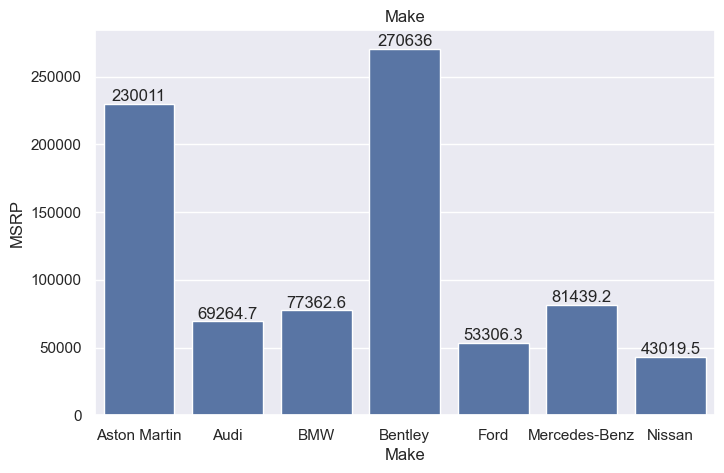

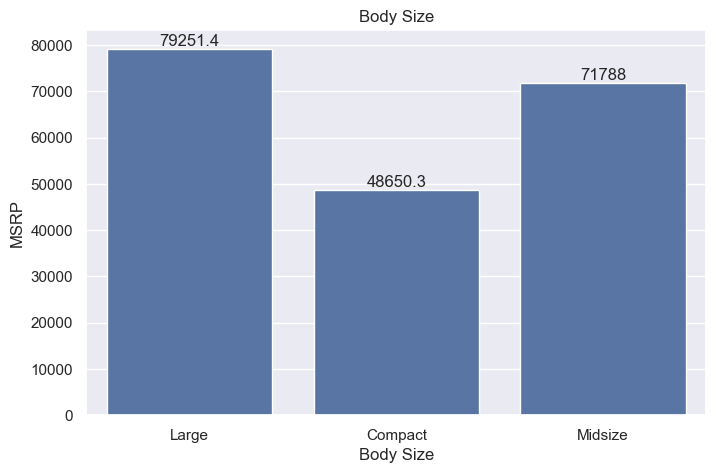

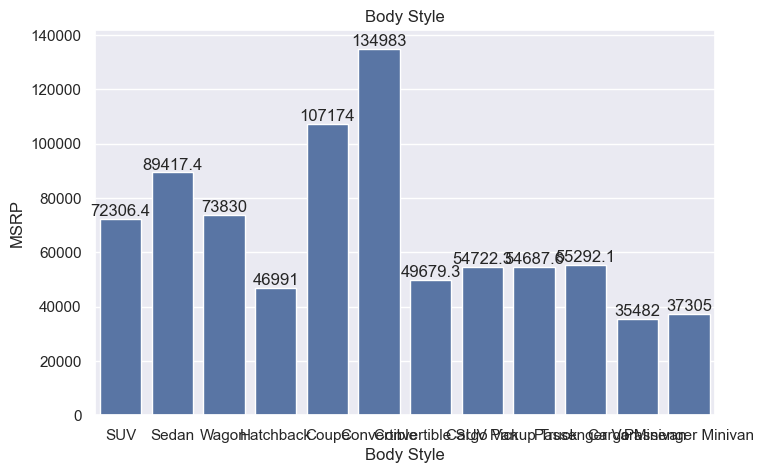

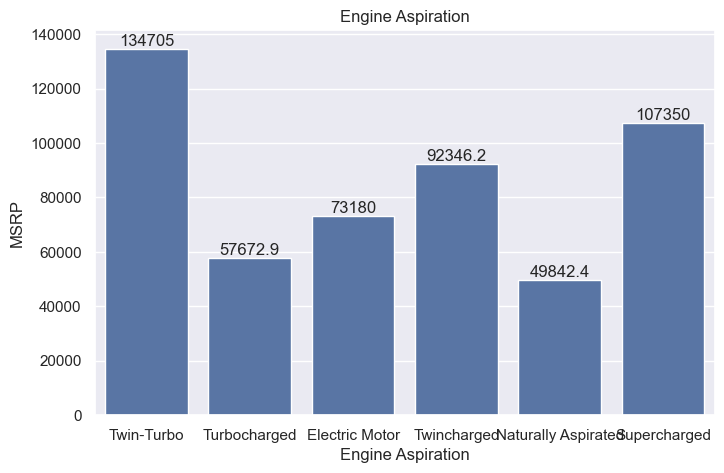

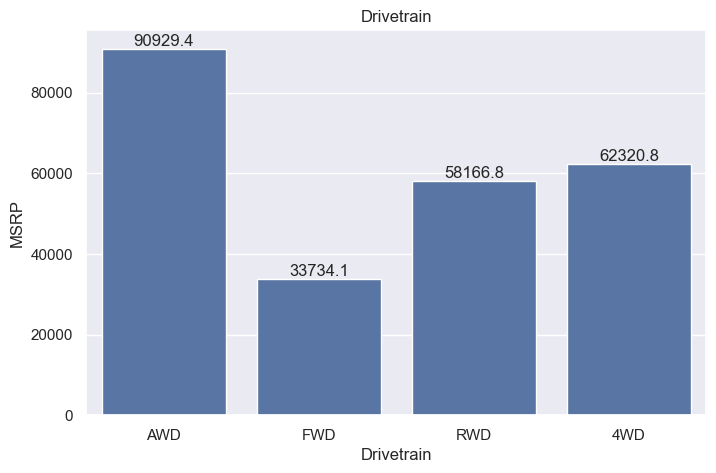

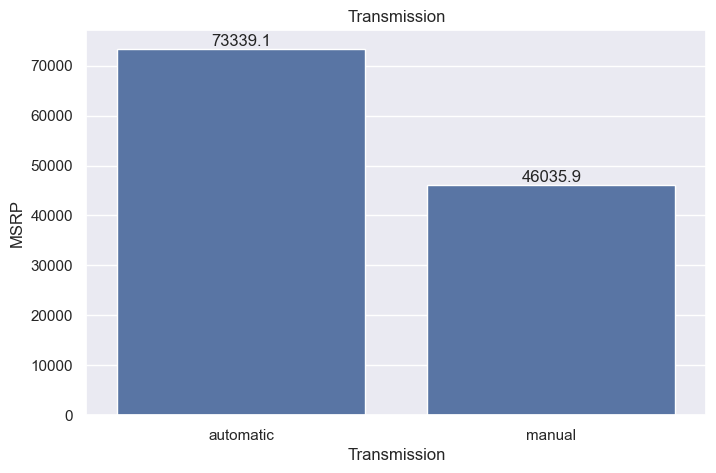

In [48]:
#visualising all my categorical variables

categories = ["Make", "Body Size", "Body Style", "Engine Aspiration", "Drivetrain", "Transmission"]

#increase the size of sns plot
sns.set(rc={"figure.figsize":(8,5)})

for c in categories:
    ax = sns.barplot(x=c, y="MSRP", data=car_data, errorbar=("ci", False))
    for container in ax.containers:
        ax.bar_label(container)
        plt.title(c)
        plt.show()

**EDA for car data**


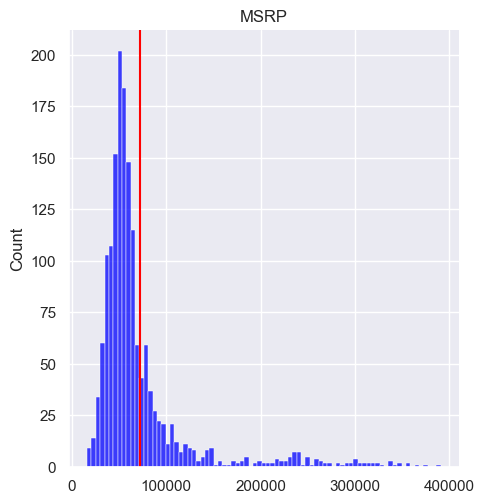

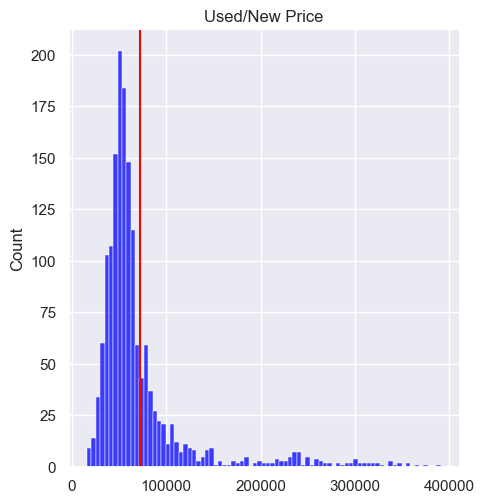

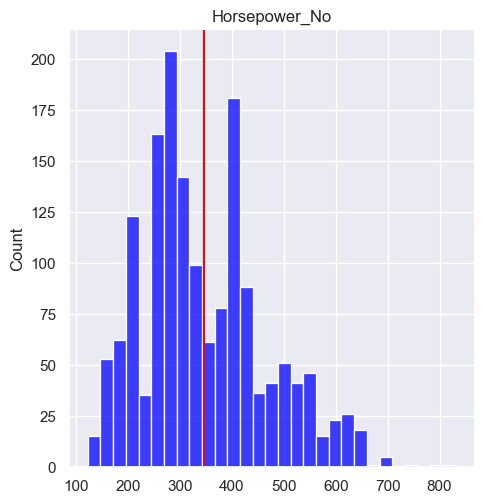

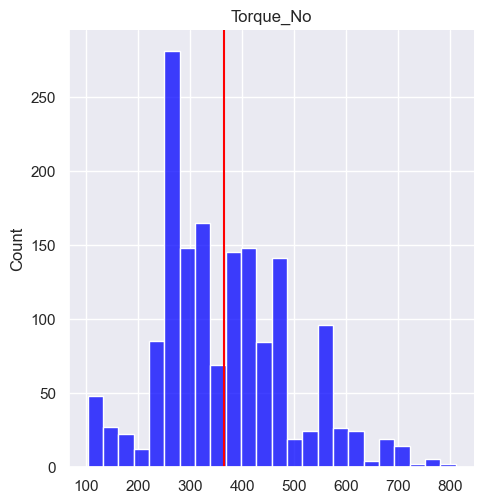

In [50]:
#Investigating the distribution of all fields, adding the mean

n_variables = ["MSRP", "Used/New Price", "Horsepower_No", "Torque_No"]

#Increase the size of sns plots

sns.set(rc={"figure.figsize": (8,5)})

for n in n_variables:
    x = car_data[n].values
    sns.displot(x, color="blue")

    #calculating the mean
    mean = car_data[n].mean()

    #plotting the mean

    plt.axvline(mean, 0,1, color="red")
    plt.title(n)
    plt.show()

The Median is:  55945.0


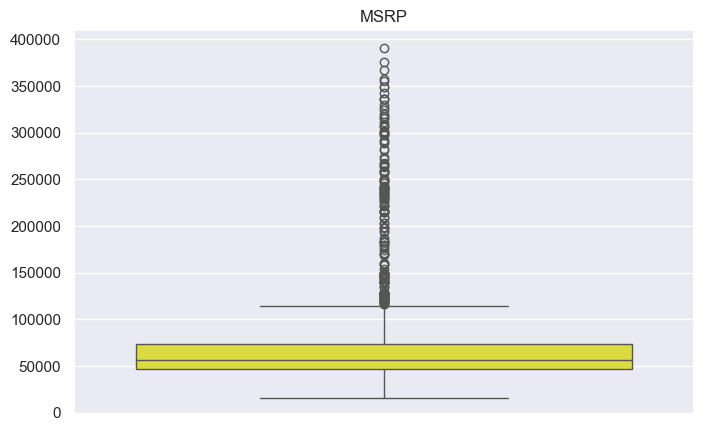

The Median is:  55945.0


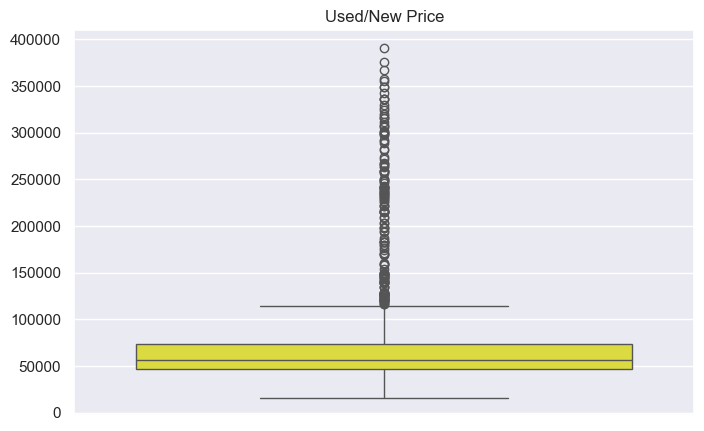

The Median is:  325.0


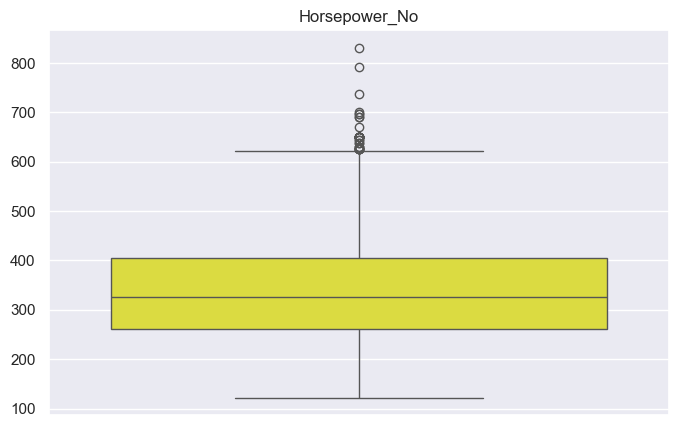

The Median is:  350.0


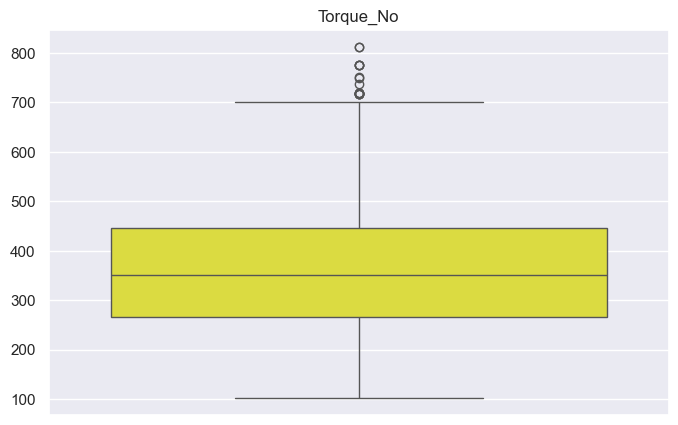

In [54]:
#Investigating the distribution of all numerical values

sns.set(rc={"figure.figsize": (8,5)})

for n in n_variables:
    x = car_data[n].values
    ax = sns.boxplot(x, color="#F5F527")

    #calculating the mean
    print("The Median is: ", car_data[n].median())

    #plotting the mean

    #plt.axvline(mean, 0,1, color="red")
    plt.title(n)
    plt.show()

C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 23.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 21.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


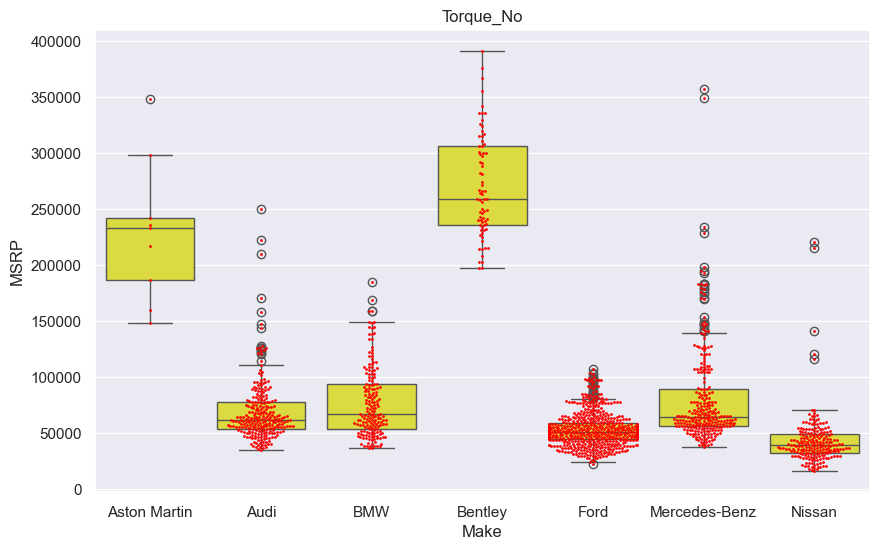

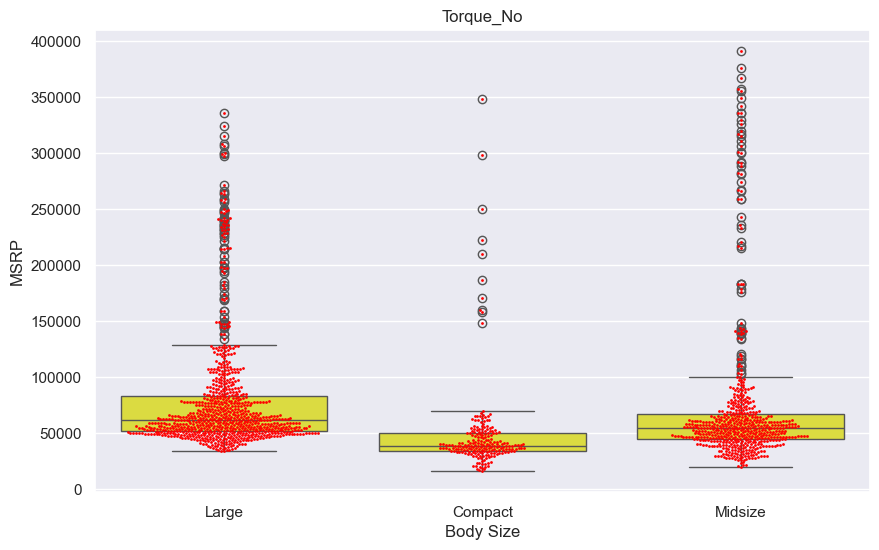

C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 15.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 14.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarni

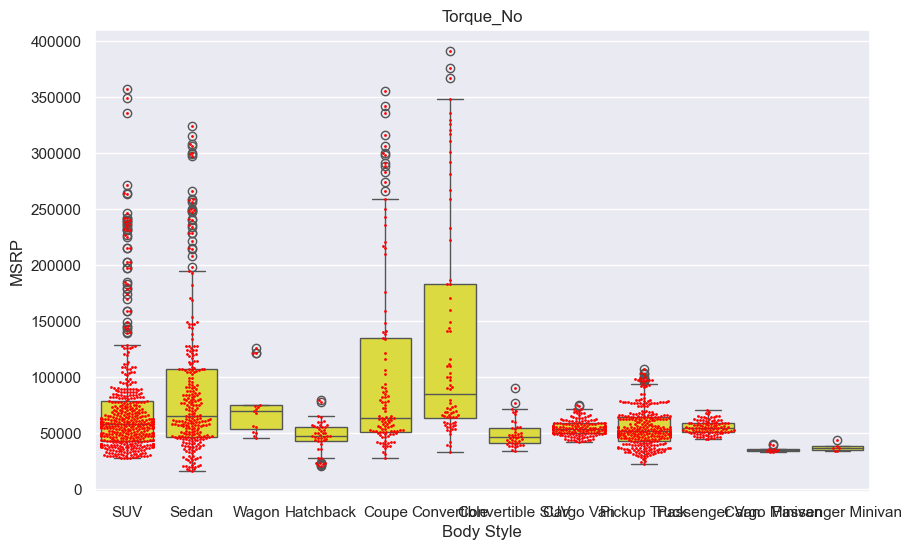

C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 10.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 13.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarnin

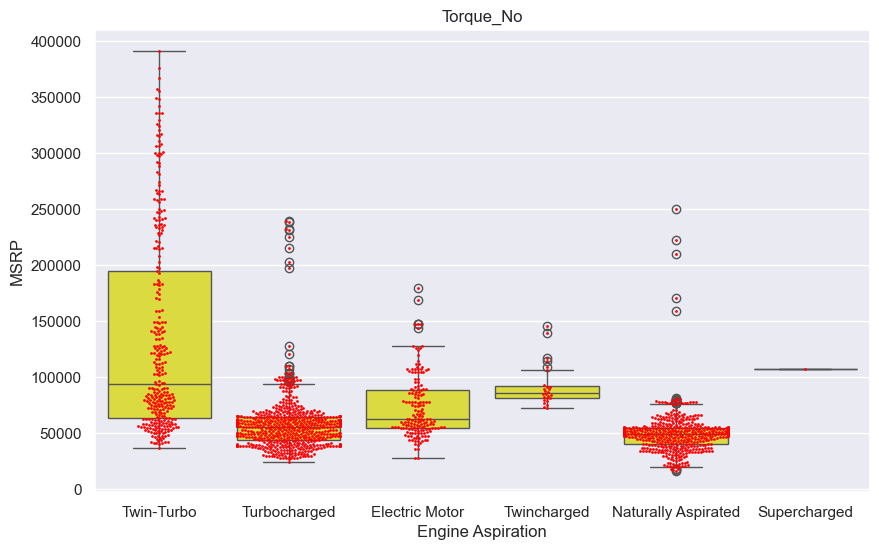

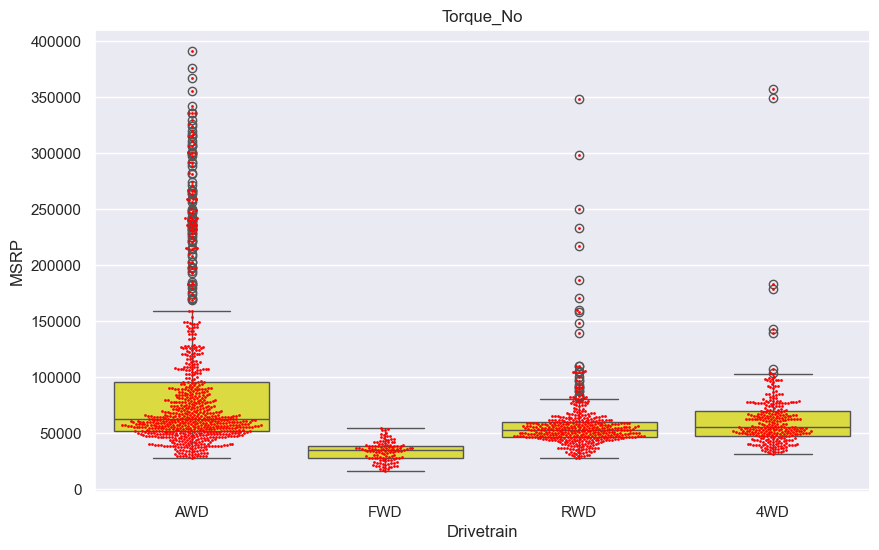

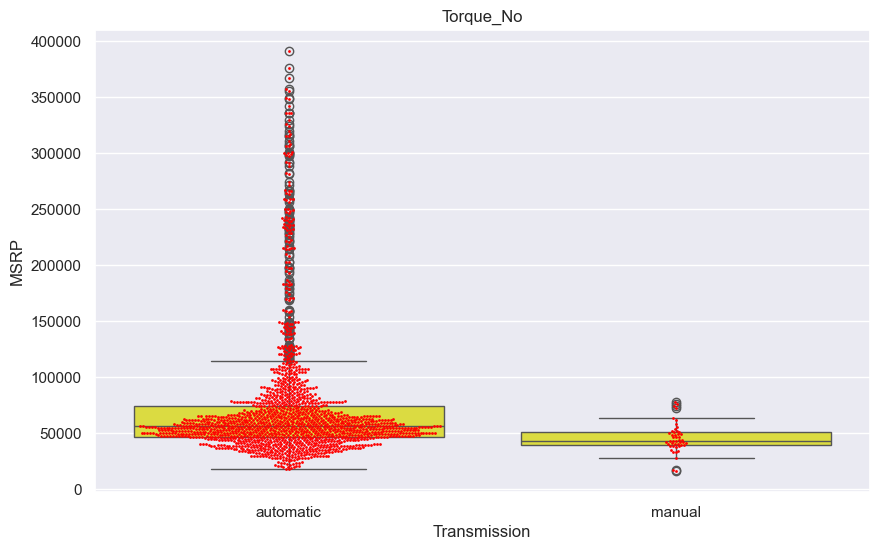

In [57]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

categories = ["Make", "Body Size", "Body Style", "Engine Aspiration", "Drivetrain", "Transmission"]

#Increase the size of sns plots

sns.set(rc={"figure.figsize": (10,6)})

for c in categories:
    ax = sns.boxplot(x=c, y="MSRP", data=car_data, color="#F5F527")
    ax = sns.swarmplot(x=c, y="MSRP", data=car_data, color="red", s=2)
    plt.title(n)
    plt.show()


**4.5 Preparing finanl DF**


In [60]:
#dropping the columns we do not need

new_car_data = car_data.drop(["index","Model", "Year","Trim", "Used/New Price", "Horsepower","Torque"], axis=1)

In [63]:
#makinng categorical variable into numeric representations
new_car_data = pd.get_dummies(new_car_data, columns = ["Make", "Body Size", "Body Style", "Engine Aspiration", "Drivetrain", "Transmission"])


KeyError: "None of [Index(['Make', 'Body Size', 'Body Style', 'Engine Aspiration', 'Drivetrain',\n       'Transmission'],\n      dtype='str')] are in the [columns]"

In [64]:
new_car_data.head()

,MSRP,Horsepower_No,Torque_No,Make_Aston Martin,Make_Audi,Make_BMW,Make_Bentley,Make_Ford,Make_Mercedes-Benz,Make_Nissan,...,Engine Aspiration_Supercharged,Engine Aspiration_Turbocharged,Engine Aspiration_Twin-Turbo,Engine Aspiration_Twincharged,Drivetrain_4WD,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD,Transmission_automatic,Transmission_manual
0,242000.0,697.0,663.0,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
1,35800.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
2,37800.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,41400.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
4,39400.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False


**4.6 Correlation & Feature Importance**


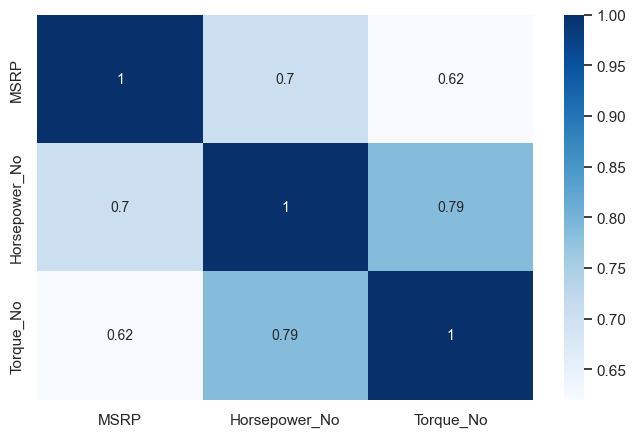

In [68]:
#Correlation with heatmap

sns.set(rc={"figure.figsize": (8,5)})

n_variables = ["MSRP", "Horsepower_No", "Torque_No"]

pc = new_car_data[n_variables].corr(method="pearson")

cols = n_variables

ax = sns.heatmap(pc, annot=True, yticklabels=cols,xticklabels=cols,annot_kws ={"size":10},cmap="Blues")

**Feature Importance**

1. split the datasets,
2. run a tree base estimator (Decision tree & randomforest)
3. run feature importance 

In [71]:
#split the data into x & y

x = new_car_data.drop(["MSRP"], axis= 1).values
x_columns  = new_car_data.drop(["MSRP"], axis=1)
y = new_car_data["MSRP"].astype(int)


print(x.shape)
print(y.shape)

#Run a Tree-based estimator (i.e decision tree & random forest)

dt = DecisionTreeClassifier(random_state=15, criterion = "entropy", max_depth=10)
dt.fit(x,y)

(1610, 36)
(1610,)


C:\Users\Nnamdi Kelvin\AppData\Roaming\Python\Python314\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",15
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [93]:
#calculating the feature importance 

for i, column in enumerate(new_car_data.drop("MSRP", axis=1)):
    print("Importance of Feature {}:, {:.3f}".format(column, dt.feature_importances_[i]))

    fi = pd.DataFrame({"Variable": [column], "Feature Importance score": [dt.feature_importances_[i]]})

    try:
        final_fi = pd.concat([final_fi, fi], ignore_index = True)
    except:
        final_fi = fi


final_fi = final_fi.sort_values("Feature Importance score", ascending = False).reset_index()
final_fi

Importance of Feature Horsepower_No:, 0.247
Importance of Feature Torque_No:, 0.123
Importance of Feature Make_Aston Martin:, 0.000
Importance of Feature Make_Audi:, 0.023
Importance of Feature Make_BMW:, 0.014
Importance of Feature Make_Bentley:, 0.013
Importance of Feature Make_Ford:, 0.124
Importance of Feature Make_Mercedes-Benz:, 0.021
Importance of Feature Make_Nissan:, 0.006
Importance of Feature Body Size_Compact:, 0.021
Importance of Feature Body Size_Large:, 0.043
Importance of Feature Body Size_Midsize:, 0.032
Importance of Feature Body Style_Cargo Minivan:, 0.001
Importance of Feature Body Style_Cargo Van:, 0.025
Importance of Feature Body Style_Convertible:, 0.007
Importance of Feature Body Style_Convertible SUV:, 0.001
Importance of Feature Body Style_Coupe:, 0.008
Importance of Feature Body Style_Hatchback:, 0.000
Importance of Feature Body Style_Passenger Minivan:, 0.001
Importance of Feature Body Style_Passenger Van:, 0.001
Importance of Feature Body Style_Pickup Truck

,index,Variable,Feature Importance score
0,0,Horsepower_No,0.246967
1,6,Make_Ford,0.123919
2,1,Torque_No,0.122594
3,27,Engine Aspiration_Turbocharged,0.087128
4,10,Body Size_Large,0.042774
5,21,Body Style_SUV,0.032605
6,11,Body Size_Midsize,0.031677
7,33,Drivetrain_RWD,0.031109
8,25,Engine Aspiration_Naturally Aspirated,0.028327
9,30,Drivetrain_4WD,0.028094


**5. Splitting the Raw Data -  Hold-out validation**

In [95]:
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=15)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1288, 36)
(322, 36)
(1288,)
(322,)


**6. Running Regression**

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error, mean_squared_error
from math import sqrt

#training the regression
model = LinearRegression(fit_intercept = True)
model.fit(X_train, y_train)

y_pred = model.predict(X_train)


In [97]:
print(y_pred)

[122494.09407531  28645.20954929  52632.70711056 ...  65452.2055744
  38169.56174495  52792.13562542]


In [100]:
result_df = pd.DataFrame({
    "Actual":y_train,
    "Predicted": y_pred
})


print(result_df.head())

      Actual      Predicted
589   198300  122494.094075
704    30110   28645.209549
367    51530   52632.707111
60     58500   70411.739329
1290   36475   35938.750000


In [101]:
all_df_predict = model.predict(x)

In [115]:
#model Accuracy on training dataset

print("The Accuracy on the training dataset is: ", model.score(X_train, y_train))
print("The Accuracy r2 on the training dataset prediction is: ", r2_score(y_train, y_pred))

print("")
#Model Accurracy On Testing datasets
print("The Accuracy on the testing datasets is: ", model.score(X_test, y_test))

print("")
#The Root Mean Squared Error (RMSE)
print("The RMSE on the training dataset is: ", sqrt(mean_squared_error(y_train, y_pred)))
print("The RMSE on the testing dataset is: ", sqrt(mean_squared_error(y_test, model.predict(X_test))))

print("")
#The Mean Absolute Error(MAE)
print("The MAE on the training datasets is: ", mean_absolute_error(y_train,y_pred))
print("The MAE on the testing datasets is: ", mean_absolute_error(y_test, model.predict(X_test)))

print("")
#coefficient
print("Coefficient", model.coef_)


#The intercept
print("Intercept", model.intercept_)




The Accuracy on the training dataset is:  0.895779183244086
The Accuracy r2 on the training dataset prediction is:  0.895779183244086

The Accuracy on the testing datasets is:  0.9198625302493008

The RMSE on the training dataset is:  17421.7784480966
The RMSE on the testing dataset is:  16534.594571973663

The MAE on the training datasets is:  10599.011937878482
The MAE on the testing datasets is:  11090.08834959268

Coefficient [ 2.22742940e+02 -1.89829669e+01  5.56034182e+04 -2.91161207e+04
 -3.66042366e+04  1.16226113e+05 -4.43839570e+04 -1.62628570e+04
 -4.54623600e+04  9.29404094e+01 -1.88423591e+02  9.54831816e+01
  6.09802309e+02  8.15969817e+03  1.42360673e+04  1.18332658e+02
  6.41353581e+02 -4.42967483e+03  6.15846845e+03  8.27078966e+03
 -1.77754623e+04 -5.15286113e+03 -3.70758421e+03 -7.12892964e+03
  6.29975752e+03  1.80270043e+03 -1.34977391e+04 -2.53004586e+02
  1.07576585e+04 -5.10937274e+03  4.83989383e+03 -3.37471593e+03
  4.33305973e+03 -5.79823762e+03  1.03945164e+

**7. Storing our model**

In [117]:
#storing the ml model
with open("linear_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [122]:
#storing the feature Importance

final_fi["Feature Importance score"] = final_fi["Feature Importance score"].round(4)
final_fi = final_fi.head(27)
final_fi.to_excel("feature_importance.xlsx")

In [119]:
#adding the predicted values

car_data["MSRP Predictions"] = all_df_predict


#exporting all the data with predictions

car_data.to_excel("data_with_pred.xlsx")

In [129]:
car_data["Engine Aspiration"].unique()

<StringArray>
[         'Twin-Turbo',        'Turbocharged',      'Electric Motor',
         'Twincharged', 'Naturally Aspirated',        'Supercharged']
Length: 6, dtype: str

**8. Streamlit App - Deployments**

8.1 Gathering input

In [135]:
#function to gather all of our input

#feature selection

def get_user_input():
    horsepower = st.sidebar.number_input("Horsepower (No)", min_value =0, max_value=1000,step=1, value=300)
    torque = st.sidebar.number_input("Torque (No)", min_value=0, max_value=1500, step=1, value=400)

    make = st.sidebar.selectbox("Make", ['Aston Martin', 'Audi', 'BMW', 'Bentley', 'Ford', 'Mercedes-Benz', 'Nissan'])
    body_size = st.sidebar.selectbox("Body Size",['Large', 'Compact', 'Midsize'])
    body_style = st.sidebar.selectbox("Body Style",[
        'SUV','Sedan','Wagon',
        'Hatchback', 'Coupe', 'Convertible', 
        'Convertible SUV', 'Cargo Van','Pickup Truck',
        'Passenger Van', 'Cargo Minivan', 'Passenger Minivan'
    ])
    engine_aspiration = st.sidebar.selectbox("Engine Aspiration",['Twin-Turbo', 'Turbocharged','Electric Motor',
         'Twincharged', 'Naturally Aspirated', 'Supercharged'])
    drivetrain = st.sidebar.selectbox("Drivetrain",["4WD", "AWD", "FWD", "RWD"])
    transmission = st.sidebar.selectbox("Transmission", ["automatic", "manual"])

    user_data = {
        "Horsepower_No" : horsepower,
        "Torque_No" : torque,
        f"Make_{make}": 1,
        f"Body Size_{body_size}": 1,
        f"Body Style_{body_style}" : 1,
        f"Engine Aspiration_{engine_aspiration}": 1,
        f"Drivetrain_{drivetrain}": 1,
        f"Transmission_{transmission}": 1
    }
    return user_data

user_data = get_user_input()

user_data

    

2026-05-23 08:51:19.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.179 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 08:51:19.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

{'Horsepower_No': 300,
 'Torque_No': 400,
 'Make_Aston Martin': 1,
 'Body Size_Large': 1,
 'Body Style_SUV': 1,
 'Engine Aspiration_Twin-Turbo': 1,
 'Drivetrain_4WD': 1,
 'Transmission_automatic': 1}

In [137]:
x_columns.columns

Index(['Horsepower_No', 'Torque_No', 'Make_Aston Martin', 'Make_Audi',
       'Make_BMW', 'Make_Bentley', 'Make_Ford', 'Make_Mercedes-Benz',
       'Make_Nissan', 'Body Size_Compact', 'Body Size_Large',
       'Body Size_Midsize', 'Body Style_Cargo Minivan', 'Body Style_Cargo Van',
       'Body Style_Convertible', 'Body Style_Convertible SUV',
       'Body Style_Coupe', 'Body Style_Hatchback',
       'Body Style_Passenger Minivan', 'Body Style_Passenger Van',
       'Body Style_Pickup Truck', 'Body Style_SUV', 'Body Style_Sedan',
       'Body Style_Wagon', 'Engine Aspiration_Electric Motor',
       'Engine Aspiration_Naturally Aspirated',
       'Engine Aspiration_Supercharged', 'Engine Aspiration_Turbocharged',
       'Engine Aspiration_Twin-Turbo', 'Engine Aspiration_Twincharged',
       'Drivetrain_4WD', 'Drivetrain_AWD', 'Drivetrain_FWD', 'Drivetrain_RWD',
       'Transmission_automatic', 'Transmission_manual'],
      dtype='str')

**8.2 Transforming the inputs**

In [138]:
#Transform the input the require formats

def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])


#feature list(same order in model training)

features = [
    'Horsepower_No', 'Torque_No', 'Make_Aston Martin', 'Make_Audi',
    'Make_BMW', 'Make_Bentley', 'Make_Ford', 'Make_Mercedes-Benz',
    'Make_Nissan', 'Body Size_Compact', 'Body Size_Large',
    'Body Size_Midsize', 'Body Style_Cargo Minivan', 'Body Style_Cargo Van',
    'Body Style_Convertible', 'Body Style_Convertible SUV',
    'Body Style_Coupe', 'Body Style_Hatchback',
    'Body Style_Passenger Minivan', 'Body Style_Passenger Van',
    'Body Style_Pickup Truck', 'Body Style_SUV', 'Body Style_Sedan',
    'Body Style_Wagon', 'Engine Aspiration_Electric Motor',
    'Engine Aspiration_Naturally Aspirated',
    'Engine Aspiration_Supercharged', 'Engine Aspiration_Turbocharged',
    'Engine Aspiration_Twin-Turbo', 'Engine Aspiration_Twincharged',
    'Drivetrain_4WD', 'Drivetrain_AWD', 'Drivetrain_FWD', 'Drivetrain_RWD',
    'Transmission_automatic', 'Transmission_manual'
]

input_array =  prepare_input(user_data, features)
input_array


array([[300, 400,   1,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,
          0,   0,   1,   0,   1,   0,   0,   0,   1,   0]])

**8.3 Making the Predictions**

In [142]:
#predictions
predictions = model.predict(input_array)
predictions

array([159674.10999106])

**8.4 Creating the Bar graph**

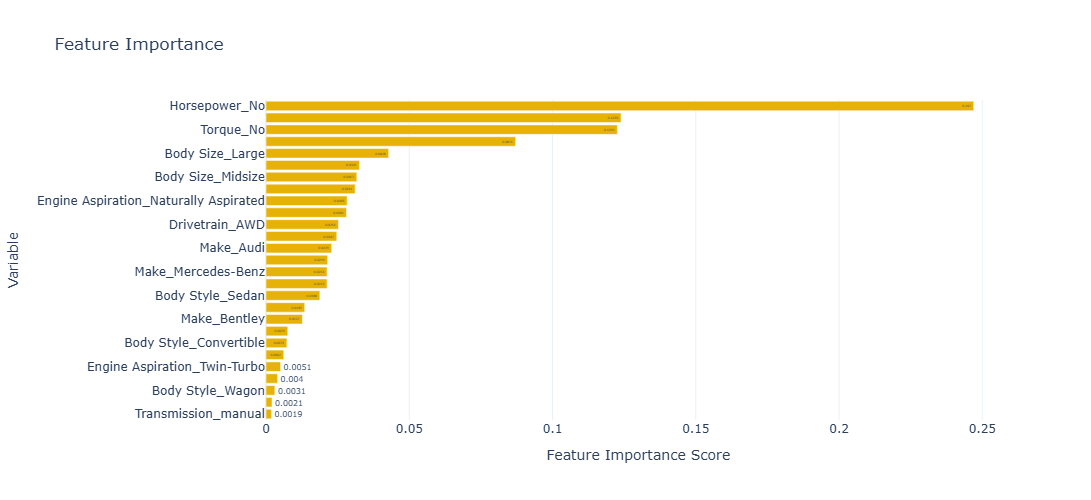

In [151]:
#creating our bar chart

#sort features importance DataFrame by "feature importance Score"
fi_sorted = final_fi.sort_values(by="Feature Importance score",  ascending=True)

#creating interactive bar chart with plotly
fig = px.bar(
    fi_sorted,
    x="Feature Importance score",
    y="Variable",
    orientation = "h",
    title = "Feature Importance ",
    labels= {"Feature Importance score": "Importance", "Variable": "Feature"},
    text="Feature Importance score",
    color_discrete_sequence = ["#e6b207"] #custom bar color
)
fig.update_layout(
    xaxis_title="Feature Importance Score",
    yaxis_title ="Variable",
    template= "plotly_white",
    height = 500
)

fig.show()

**8.5 creating App**

In [152]:
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import plotly.express as px
from PIL import Image

#page configuration
st.set_page_config(layout="wide")

#load your pre-load model

with open("linear_model.pkl", "rb") as f:
    lm2 = pickle.load(f)

#load feature Importance from the excel file
def load_feature_importance(file_path):
    return pd.read_excel(file_path)

#load feature importance  into dataFrame

final_fi = load_feature_importaance("ml/feature_importance.xlsx")

#sidebar setup
image_sidebar = Image.open("Pic 1.png")
st.sidebar.image(image_sidebar, use_column_width=True)
st.sidebar.header("Vehicle Features")

#feature selection for sidebar


def get_user_input():
    horsepower = st.sidebar.number_input("Horsepower (No)", min_value =0, max_value=1000,step=1, value=300)
    torque = st.sidebar.number_input("Torque (No)", min_value=0, max_value=1500, step=1, value=400)

    make = st.sidebar.selectbox("Make", ['Aston Martin', 'Audi', 'BMW', 'Bentley', 'Ford', 'Mercedes-Benz', 'Nissan'])
    body_size = st.sidebar.selectbox("Body Size",['Large', 'Compact', 'Midsize'])
    body_style = st.sidebar.selectbox("Body Style",[
        'SUV','Sedan','Wagon',
        'Hatchback', 'Coupe', 'Convertible', 
        'Convertible SUV', 'Cargo Van','Pickup Truck',
        'Passenger Van', 'Cargo Minivan', 'Passenger Minivan'
    ])
    engine_aspiration = st.sidebar.selectbox("Engine Aspiration",['Twin-Turbo', 'Turbocharged','Electric Motor',
         'Twincharged', 'Naturally Aspirated', 'Supercharged'])
    drivetrain = st.sidebar.selectbox("Drivetrain",["4WD", "AWD", "FWD", "RWD"])
    transmission = st.sidebar.selectbox("Transmission", ["automatic", "manual"])

    user_data = {
        "Horsepower_No" : horsepower,
        "Torque_No" : torque,
        f"Make_{make}": 1,
        f"Body Size_{body_size}": 1,
        f"Body Style_{body_style}" : 1,
        f"Engine Aspiration_{engine_aspiration}": 1,
        f"Drivetrain_{drivetrain}": 1,
        f"Transmission_{transmission}": 1
    }
    return user_data

#top banner
image_banner = Image.open("Pic 2.png")
st.Image(image_banner, use_column_width=True)

#centre title
st.markdown("<h1 stlye='text-align: center;'>Vehicle Price Predictions App</h1>", unsafe_allow_html=True)

#split layout into two columns
left_col, right_col = st.columns(2)

#left column: Feature Importance Interactive chart

with left_col:
    st.header("Feature Importance")

    #sort features importance DataFrame by "feature importance Score"
fi_sorted = final_fi.sort_values(by="Feature Importance score",  ascending=True)

#creating interactive bar chart with plotly
fig = px.bar(
    fi_sorted,
    x="Feature Importance score",
    y="Variable",
    orientation = "h",
    title = "Feature Importance ",
    labels= {"Feature Importance score": "Importance", "Variable": "Feature"},
    text="Feature Importance score",
    color_discrete_sequence = ["#e6b207"] #custom bar color
)
fig.update_layout(
    xaxis_title="Feature Importance Score",
    yaxis_title ="Variable",
    template= "plotly_white",
    height = 500
)

st.plotly_chart(fig, use_container_width=True)

#right column: Prediction Interface

with right_col:
    st.header("Predict Vehicle Price")

    #user input from sidebar

    user_data = get_user_input()

    #Transform the input the require formats

def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])


#feature list(same order in model training)

features = [
    'Horsepower_No', 'Torque_No', 'Make_Aston Martin', 'Make_Audi',
    'Make_BMW', 'Make_Bentley', 'Make_Ford', 'Make_Mercedes-Benz',
    'Make_Nissan', 'Body Size_Compact', 'Body Size_Large',
    'Body Size_Midsize', 'Body Style_Cargo Minivan', 'Body Style_Cargo Van',
    'Body Style_Convertible', 'Body Style_Convertible SUV',
    'Body Style_Coupe', 'Body Style_Hatchback',
    'Body Style_Passenger Minivan', 'Body Style_Passenger Van',
    'Body Style_Pickup Truck', 'Body Style_SUV', 'Body Style_Sedan',
    'Body Style_Wagon', 'Engine Aspiration_Electric Motor',
    'Engine Aspiration_Naturally Aspirated',
    'Engine Aspiration_Supercharged', 'Engine Aspiration_Turbocharged',
    'Engine Aspiration_Twin-Turbo', 'Engine Aspiration_Twincharged',
    'Drivetrain_4WD', 'Drivetrain_AWD', 'Drivetrain_FWD', 'Drivetrain_RWD',
    'Transmission_automatic', 'Transmission_manual'
]


#predict button

if st.button("Predict"):
    input_array = prepare_input(user_data, features)
    prediction = lm2.predict(input_array)
    st.subheader("Predicted Price")
    st.write(f"${prediction[0]:,.2f}")


#streamlit run Regr_model_cars.py

    

    

    


    

    

2026-05-24 07:23:19.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name 'load_feature_importaance' is not defined